First 5 Rows:

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None

Statistical Summary:

       total_bill         tip        size
count  244.000000  244.

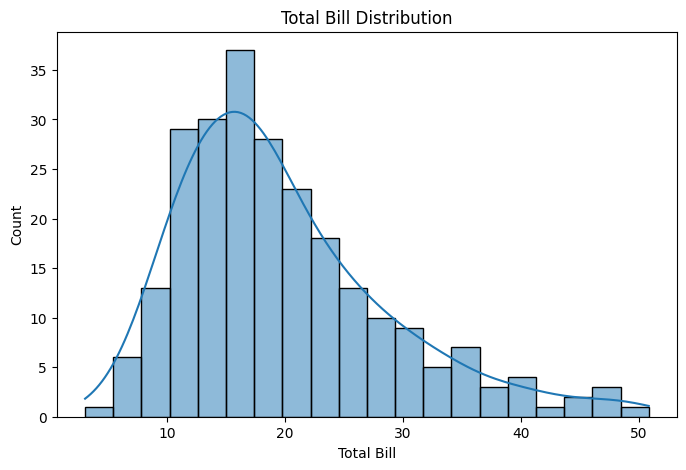

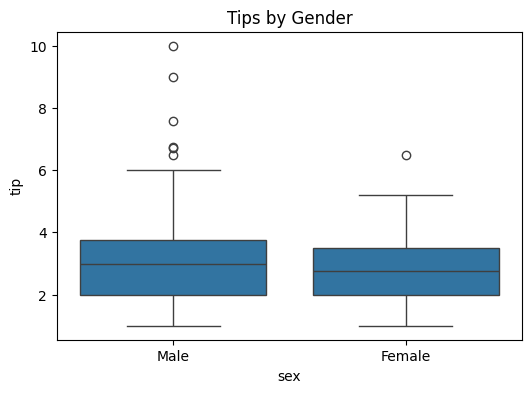

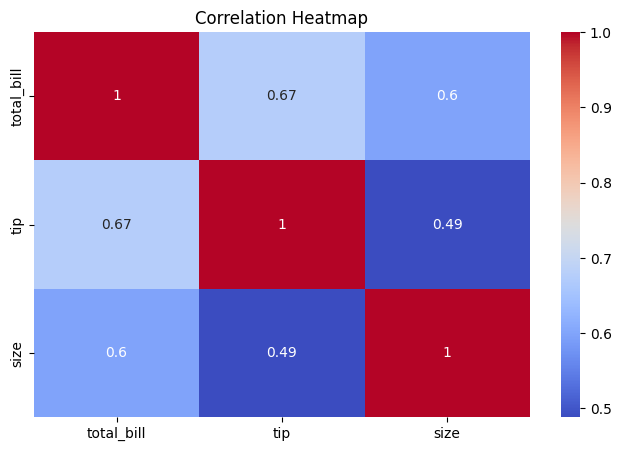

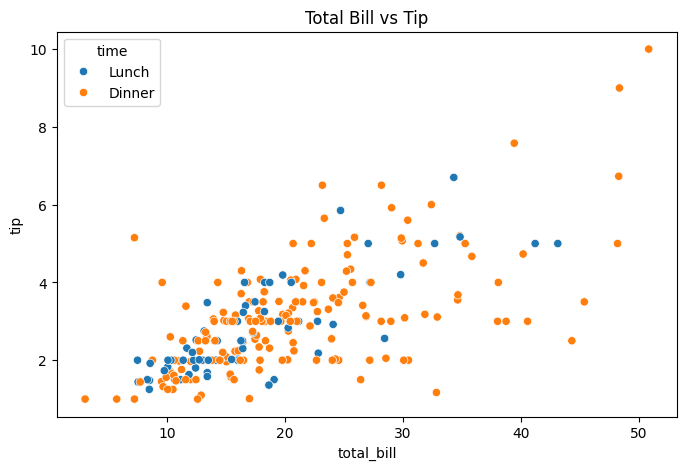


========== MODEL PERFORMANCE ==========
Mean Absolute Error: 0.77
R2 Score: 0.52


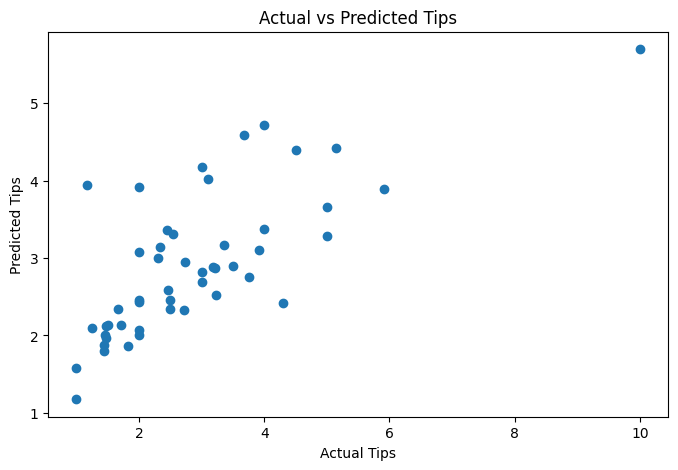


========== KEY FINDINGS ==========
1. Higher total bills generally result in higher tips.
2. Strong positive correlation exists between total bill and tip.
3. Dinner customers tend to give larger tips.
4. The prediction model performs reasonably well.

Project Completed Successfully


In [1]:
# =========================================================
# Domain-Specific Data Science Project
# Sales Data Analysis and Prediction
# =========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# =========================================================
# Load Built-in Dataset
# =========================================================

# Using seaborn tips dataset as sales-like business dataset
df = sns.load_dataset('tips')

# =========================================================
# 1. Dataset Overview
# =========================================================

print("First 5 Rows:\n")
print(df.head())

print("\nDataset Information:\n")
print(df.info())

print("\nStatistical Summary:\n")
print(df.describe())

# =========================================================
# 2. Data Cleaning
# =========================================================

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

print("\nDuplicates Removed Successfully")

# =========================================================
# 3. Data Visualization
# =========================================================

# Total Bill Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['total_bill'], bins=20, kde=True)

plt.title("Total Bill Distribution")
plt.xlabel("Total Bill")

plt.show()

# =========================================================
# Tips by Gender
# =========================================================

plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='tip', data=df)

plt.title("Tips by Gender")

plt.show()

# =========================================================
# Correlation Heatmap
# =========================================================

plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# =========================================================
# Relationship Between Total Bill and Tip
# =========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(x='total_bill',
                y='tip',
                hue='time',
                data=df)

plt.title("Total Bill vs Tip")

plt.show()

# =========================================================
# 4. Feature Engineering
# =========================================================

# Convert categorical columns into numeric
df_encoded = pd.get_dummies(df, drop_first=True)

# =========================================================
# 5. Prediction Model
# Predicting Tip Amount
# =========================================================

X = df_encoded.drop('tip', axis=1)
y = df_encoded['tip']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = LinearRegression()

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# =========================================================
# 6. Model Evaluation
# =========================================================

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# =========================================================
# 7. Actual vs Predicted Visualization
# =========================================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")

plt.title("Actual vs Predicted Tips")

plt.show()

# =========================================================
# 8. Key Findings
# =========================================================

print("\n========== KEY FINDINGS ==========")

print("1. Higher total bills generally result in higher tips.")
print("2. Strong positive correlation exists between total bill and tip.")
print("3. Dinner customers tend to give larger tips.")
print("4. The prediction model performs reasonably well.")

print("\nProject Completed Successfully")